In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = sns.load_dataset("titanic")

features = ['age', 'fare', 'sibsp', 'parch', 'pclass']

X = df[features].copy()

X = X.fillna(X.median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance:",
      pca.explained_variance_ratio_.sum())

Explained Variance: 0.6648159969553278


In [2]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_pca)

score = silhouette_score(X_pca, clusters)

print("Silhouette Score:", round(score, 4))

Silhouette Score: 0.4736


C:\Users\Shanmukha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


In [3]:
df['Cluster'] = clusters

print("\nCluster Counts:")
print(df['Cluster'].value_counts())


Cluster Counts:
Cluster
0    639
1    252
Name: count, dtype: int64


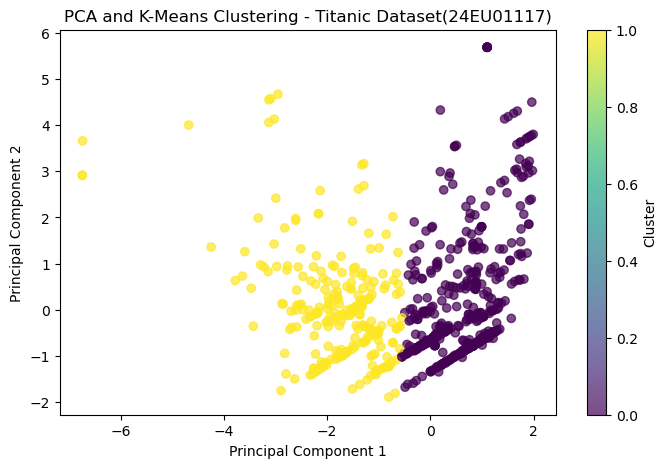

In [5]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap='viridis',
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA and K-Means Clustering - Titanic Dataset(24EU01117)")
plt.colorbar(label="Cluster")

plt.show()